# Model Analysis: CME Futures

This notebook evaluates all predictive models trained on the CME futures
case study and answers a single question: **which learned signals are real,
stable, and worth taking into a backtest?**

The CME futures universe spans 30 products across seven sectors — equity
indices (ES, NQ, YM, RTY), treasuries (ZN, ZB, ZF, ZT), energy (CL, NG,
HO, RB), metals (GC, SI, HG, PL), currencies (6E, 6J, 6B, 6A, 6C, 6S),
agriculture (ZC, ZS, ZW, ZM, ZL), and livestock (LE, HE, GF). This is
a cross-sectional prediction problem over a structurally diverse asset
class where the dominant signal is **carry** — the return earned from
holding a futures position through time, driven by the term structure
slope between front and deferred contracts.

Unlike equities or ETFs where price momentum and mean reversion dominate,
futures returns decompose into a spot return and a roll return. The roll
return is mechanical: long positions in contango markets (where deferred
contracts trade above the front) lose value as the contract rolls toward
expiry; backwardated markets pay longs. This carry premium is one of the
most documented risk premia in finance, historically delivering 3–5%
annualized for diversified portfolios.

With 5 walk-forward folds and a weekly prediction horizon (`fwd_ret_5d`),
the dataset provides moderate statistical evidence across diverse market
conditions. The feature set (63 features) emphasizes carry and term
structure signals — carry percentage, carry z-scores, roll proximity,
curvature — alongside momentum at multiple horizons, volatility measures,
and seasonality indicators.

**Learning Objectives**:
- Apply a structured model evaluation workflow to a commodity futures dataset
- Distinguish mean performance from fold-level stability
- Diagnose whether models learn different or redundant signals
- Use regime conditioning to understand when carry signals strengthen or weaken
- Make explicit, evidence-based decisions about which models to backtest

**Data note**: All IC and prediction metrics are computed against
forward return labels derived from **ratio back-adjusted** continuous
contracts (multiplicative adjustment at roll points). Ratio adjustment
removes the price-gap artifact at roll transitions that would
otherwise create spurious carry-return correlation in the labels.
See [`02_labels`](02_labels.ipynb) and Ch2
[`06_futures_continuous`](../../02_financial_data_universe/06_futures_continuous.ipynb)
for the construction and a discussion of why this adjustment is
load-bearing for futures research.

**Prerequisites**: Model training notebooks Ch11-15 must have run for this
case study. Linear, GBM, TabM, LSTM, SDF, and causal DML results come
from the registry — all five modeling chapters are represented.

**Book Reference**: This notebook bridges Part III (Models, Ch11–15) and
Part IV (Strategy Implementation, Ch16–20). The chapter insights notebooks
in Ch11–15 compare each model family *across* case studies; here we compare
all families *within* a single dataset.

In [1]:
"""Model Analysis: CME Futures — comparative evaluation across all model families."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml

from case_studies.utils.latent_factors import load_fold_extras
from case_studies.utils.model_analysis import (
    fold_performance_matrix,
    load_all_metrics,
    load_fold_metrics_from_registry,
    load_gbm_feature_importance,
    load_predictions,
    prediction_bucket_monotonicity,
    prediction_correlation_matrix,
    regime_conditional_ic,
)
from case_studies.utils.model_viz import (
    plot_bucket_monotonicity,
    plot_correlation_matrix,
    plot_cv_timeline,
    plot_feature_importance_heatmap,
    plot_fold_boxplot,
    plot_fold_heatmap,
    plot_label_horizon_forest,
    plot_learning_curves,
    plot_regime_bars,
)
from case_studies.utils.notebook_render import conformal_coverage_diagnostic
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY = "cme_futures"
PRIMARY_LABEL = "fwd_ret_5d"
DATE_COL = "timestamp"
ENTITY_COL = "product"  # NOTE: futures use "product", not "symbol"
N_BUCKETS = 5  # 30 products — quintiles
TOP_N_FEATURES = 15
REGIME_WINDOW = 63

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    setup = yaml.safe_load(f)

n_splits = setup["evaluation"]["n_splits"]
train_size = setup["evaluation"]["train_size"]
val_size = setup["evaluation"]["val_size"]
holdout_start = setup["evaluation"].get("holdout_start")
n_assets = setup["universe"].get("n_assets") or setup["universe"].get("n_products", 30)

# Futures costs: commission + spread, expressed differently from ETFs
# Approximate per-leg cost in bps for liquid (ES, GC, CL) vs illiquid (LE, GF, ZL)
cost_range = setup["costs"].get("per_leg_cost_bps_range", [2, 10])

sectors = list(setup["universe"].get("product_groups", {}).keys())
products_by_sector = setup["universe"].get("product_groups", {})

print(f"Case Study: {CASE_STUDY}")
print(f"  Universe: {n_assets} products across {len(sectors)} sectors ({', '.join(sectors)})")
print(f"  Label: {PRIMARY_LABEL} (weekly rebalancing)")
print(f"  CV: {n_splits} expanding-window folds, train={train_size}, val={val_size}")
print(f"  Holdout: {holdout_start} onwards")
print(
    f"  Trading costs: ~{cost_range[0]}–{cost_range[1]} bps per leg "
    f"(commission ${setup['costs'].get('commission_per_contract', 2)}/contract + "
    f"{setup['costs'].get('spread_ticks', {}).get('liquid', 1)}–"
    f"{setup['costs'].get('spread_ticks', {}).get('illiquid', 2)} tick spread)"
)

Case Study: cme_futures
  Universe: 30 products across 7 sectors (equity_index, treasuries, energy, metals, currencies, agriculture, livestock)
  Label: fwd_ret_5d (weekly rebalancing)
  CV: 5 expanding-window folds, train=8Y, val=1Y
  Holdout: 2024-01-01 onwards
  Trading costs: ~2–10 bps per leg (commission $2.0/contract + 1–2 tick spread)


## 1. What Is the Prediction Problem?

**Primary target tuple**: `fwd_ret_5d` | regression | IC | weekly rebalancing

We predict the 5-trading-day forward return for each of 30 CME futures
products, ranking them cross-sectionally at each week-end to identify the
highest-expected-return contracts. The strategy goes long the top quintile
and short the bottom quintile, rebalancing weekly.

**Why weekly?** Monthly rebalancing is too slow for futures — roll costs
compound and term structure signals are faster-moving than equity momentum.
Daily rebalancing, conversely, generates excessive transaction costs from
bid-ask spreads and commission. The 5-day horizon strikes a balance.

The feature set (63 features) is built around the carry trade thesis:
- **Carry features** (12): `carry_pct`, `carry_rank`, `carry_zscore_63d`,
  `carry_regime_num`, `carry_momentum_5d/21d`, `carry_rank_sector` — these
  measure the slope and dynamics of the term structure
- **Momentum features** (15): `ret_5d` through `ret_252d`, `sharpe_63d/126d/252d`,
  `momentum_composite`, `ts_mom_63d/126d/252d` — cross-sectional and
  time-series momentum signals
- **Volatility features** (8): `vol_21d/63d/126d`, `vol_rank`, `vol_ratio_short/medium`,
  `vol_yz_21d`, `vr_63d` — risk normalization and regime detection
- **Technical/structural** (12): `rsi_14`, `ma_ratio_21/50/200`, `curvature_21d`,
  `dist_from_52w_high`, `roll_proximity` — contract-specific signals
- **Seasonality** (4): `day_of_year_norm`, `month_sin/cos`, `quarter`,
  `is_seasonal_sector` — agricultural and energy seasonality

The universe mixes seven sectors deliberately. Each sector has distinct
term structure dynamics: equity index futures are almost always in contango
(negative carry for longs), energy markets oscillate with supply shocks,
precious metals reflect real interest rates, and agricultural products
exhibit strong seasonality. The cross-sectional model must learn which
carry and momentum signals generalize across sectors versus those that
are sector-specific.

In [4]:
# Phase 1: Load pre-computed metrics for ALL labels (coverage + multi-label analysis)
# Note: some families (latent_factors) store label=null in the registry — assign PRIMARY_LABEL
_raw_all = load_all_metrics(CASE_STUDY, label=None)
_raw_all = _raw_all.with_columns(
    pl.when(pl.col("label").is_null())
    .then(pl.lit(PRIMARY_LABEL))
    .otherwise(pl.col("label"))
    .alias("label")
)
all_labels_metrics = _raw_all.filter(pl.col("label").is_not_null())
all_metrics = all_labels_metrics.filter(pl.col("label") == PRIMARY_LABEL)

if all_metrics.height == 0:
    raise RuntimeError(f"No metrics found for {CASE_STUDY} / {PRIMARY_LABEL}")

families_present = sorted(all_metrics["family"].unique().to_list())
print(f"Pre-computed metrics: {all_metrics.height} entries across {len(families_present)} families")

for fam in families_present:
    sub = all_metrics.filter(pl.col("family") == fam)
    configs = sub["config_name"].n_unique()
    checkpoints = sub["checkpoint_value"].drop_nulls().n_unique()
    # Rank on the daily-pooled IC (the metric the HAC credibility CIs use);
    # fall back to the fold-averaged ic_mean only where daily-pooled is absent.
    best_ic = (
        sub["ic_mean_daily"].max()
        if "ic_mean_daily" in sub.columns and sub["ic_mean_daily"].drop_nulls().len() > 0
        else sub["ic_mean"].max()
    )
    best_ic_text = f"{best_ic:+.4f}" if best_ic is not None else "n/a"
    print(
        f"  {fam:20s}  {configs:3d} configs  {checkpoints:3d} checkpoints  best IC={best_ic_text}"
    )

# Coverage completeness check. The five predictive/structural families produce
# comparable IC in prediction_metrics; causal_dml (Ch15) produces treatment
# effects in the causal_runs table instead, so it is verified separately (§7)
# rather than expected in the IC leaderboard.
EXPECTED_IC_FAMILIES = {"linear", "gbm", "tabular_dl", "deep_learning", "latent_factors"}
missing = EXPECTED_IC_FAMILIES - set(families_present)
if missing:
    n_present = len(set(families_present) & EXPECTED_IC_FAMILIES)
    print(
        f"\nWARNING — COVERAGE: {n_present}/{len(EXPECTED_IC_FAMILIES)} IC families present. "
        f"Missing: {', '.join(sorted(missing))}"
    )
    print("  Recommendations below may change when missing families are added.")
else:
    print("\nFull coverage: all 5 IC families present; causal_dml evaluated via causal_runs (§7).")

Pre-computed metrics: 63 entries across 5 families
  deep_learning           2 configs    2 checkpoints  best IC=+0.0040
  gbm                    15 configs    0 checkpoints  best IC=+0.0252
  latent_factors          2 configs    9 checkpoints  best IC=+0.0421
  linear                 24 configs    0 checkpoints  best IC=+0.0026
  tabular_dl              3 configs    4 checkpoints  best IC=+0.0078

Full coverage: all 5 IC families present; causal_dml evaluated via causal_runs (§7).


In [5]:
# Best model per family. Rank on the daily-pooled IC (`ic_mean_daily`) — the
# same metric the HAC credibility intervals are built on — rather than the
# fold-averaged `ic_mean`. The two disagree only for latent_factors, where
# `ic_mean` selects an SDF checkpoint whose daily-pooled HAC CI straddles zero,
# contradicting the credibility read below; daily-pooled ranking selects the
# checkpoint the narrative reports. `ic_mean` is then set to the daily-pooled
# value so the leaderboard and synthesis display the credibility metric.
_rank_ic = (
    pl.coalesce(["ic_mean_daily", "ic_mean"])
    if "ic_mean_daily" in all_metrics.columns
    else pl.col("ic_mean")
)
best_per_family = (
    all_metrics.filter(pl.col("ic_mean").is_not_null())
    .with_columns(_rank_ic.alias("ic_mean"))
    .sort("ic_mean", descending=True)
    .group_by("family")
    .first()
    .sort("ic_mean", descending=True)
)

print("\nBest model per family:")
print(best_per_family.select(["family", "config_name", "checkpoint_value", "ic_mean", "ic_std"]))


Best model per family:
shape: (5, 5)
┌────────────────┬───────────────┬──────────────────┬──────────┬──────────┐
│ family         ┆ config_name   ┆ checkpoint_value ┆ ic_mean  ┆ ic_std   │
│ ---            ┆ ---           ┆ ---              ┆ ---      ┆ ---      │
│ str            ┆ str           ┆ i64              ┆ f64      ┆ f64      │
╞════════════════╪═══════════════╪══════════════════╪══════════╪══════════╡
│ latent_factors ┆ sdf           ┆ 0                ┆ 0.042125 ┆ 0.026382 │
│ gbm            ┆ leaves_31_mse ┆ null             ┆ 0.025166 ┆ 0.024726 │
│ tabular_dl     ┆ tabm_l        ┆ 25               ┆ 0.007756 ┆ 0.023495 │
│ deep_learning  ┆ lstm_h64      ┆ 15               ┆ 0.00396  ┆ 0.016809 │
│ linear         ┆ enet_f0.5     ┆ null             ┆ 0.002567 ┆ 0.059534 │
└────────────────┴───────────────┴──────────────────┴──────────┴──────────┘


In [6]:
# Phase 2a: Load per-fold metrics from registry (fast path — no raw predictions needed)
fold_metrics = load_fold_metrics_from_registry(CASE_STUDY, label=PRIMARY_LABEL)
if fold_metrics.height > 0:
    print(f"Fold metrics from registry: {fold_metrics.height} entries")
else:
    print("No fold_metrics table — will compute from raw predictions")

Fold metrics from registry: 335 entries


In [7]:
# Phase 2: Load raw predictions ONLY for the ~5 best models (not all)
representative_preds = []

for row in best_per_family.filter(pl.col("family") != "causal_dml").iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    preds = load_predictions(
        CASE_STUDY,
        family=family,
        label=PRIMARY_LABEL,
        config_name=config,
        checkpoint_value=checkpoint,
    )
    # Normalize entity column: some families may use "symbol" instead of ENTITY_COL
    if preds.height > 0 and ENTITY_COL not in preds.columns:
        alt_col = "symbol" if ENTITY_COL == "product" else "product"
        if alt_col in preds.columns:
            preds = preds.rename({alt_col: ENTITY_COL})

    if preds.height > 0:
        representative_preds.append(preds)
        print(f"  Loaded {family}/{config}: {preds.height:,} predictions")

if representative_preds:
    best_preds = pl.concat(representative_preds, how="diagonal_relaxed")
    # Normalize DATE_COL to Datetime (parquets may store as Date or String)
    if best_preds.height > 0 and best_preds[DATE_COL].dtype == pl.String:
        best_preds = best_preds.with_columns(pl.col(DATE_COL).str.to_datetime())
    elif best_preds.height > 0 and best_preds[DATE_COL].dtype == pl.Date:
        best_preds = best_preds.with_columns(pl.col(DATE_COL).cast(pl.Datetime("ms")))
    print(f"\nTotal representative predictions: {best_preds.height:,}")
else:
    best_preds = pl.DataFrame()
    print("WARNING: No raw predictions could be loaded")

  Loaded latent_factors/sdf: 38,394 predictions
  Loaded gbm/leaves_31_mse: 38,394 predictions
  Loaded tabular_dl/tabm_l: 38,394 predictions
  Loaded deep_learning/lstm_h64: 38,394 predictions
  Loaded linear/enet_f0.5: 38,394 predictions

Total representative predictions: 191,970


In [8]:
# Fold date ranges for timeline
if best_preds.height > 0:
    fold_ranges = (
        best_preds.filter(pl.col("fold_id").is_not_null())
        .group_by("fold_id")
        .agg(
            pl.col(DATE_COL).min().cast(pl.Date).alias("val_start"),
            pl.col(DATE_COL).max().cast(pl.Date).alias("val_end"),
        )
        .sort("fold_id")
    )

### Figure 1: Cross-Validation Timeline

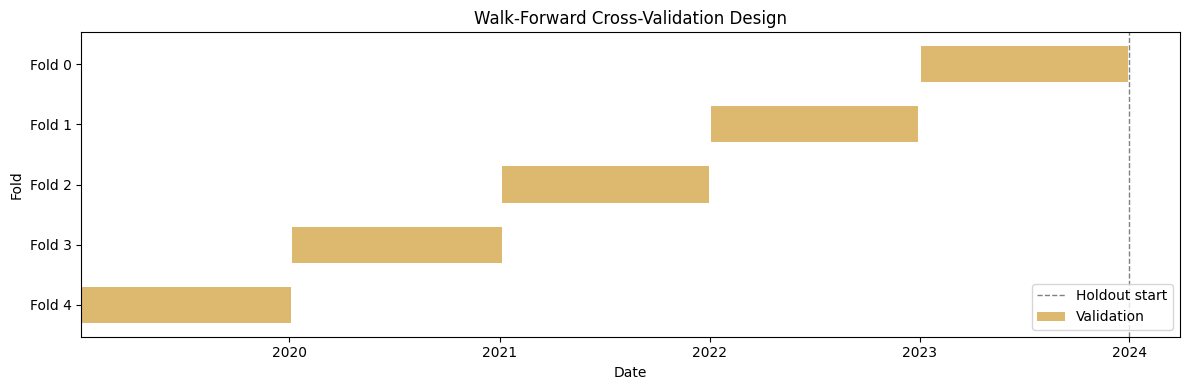

In [9]:
if best_preds.height > 0 and fold_ranges.height > 0:
    plot_cv_timeline(fold_ranges, n_splits, holdout_start)

Each fold trains on an expanding window and validates on the following
year. With 5 folds, the validation windows run one year each from 2019
(fold 4) through 2023 (fold 0), with 2024 sealed as the holdout. This span
covers the 2020 oil crisis (WTI briefly traded negative), the post-COVID
inflation surge that sent energy and agricultural futures to multi-year
highs, and the 2022–2023 normalization — both contango-dominated and
backwardation-dominated regimes, which is essential for evaluating
carry-based signals.

## 2. What Was Actually Run?

Before comparing results, we map what is actually comparable. Not all
model families were trained on all labels, and the five modeling
chapters contribute different kinds of evidence: Ch11-13 produce
predictive forecasts; Ch14 extracts latent structure; Ch15 estimates
causal effects. Forcing all of these into a single ranking would be
misleading.

In [10]:
# Coverage map: family x label x evidence type
EVIDENCE_TYPE = {
    "linear": "predictive",
    "gbm": "predictive",
    "tabular_dl": "predictive",
    "deep_learning": "predictive",
    "latent_factors": "structural",
    "causal_dml": "causal",
}
FAMILY_CHAPTER = {
    "linear": "Ch11",
    "gbm": "Ch12",
    "tabular_dl": "Ch12",
    "deep_learning": "Ch13",
    "latent_factors": "Ch14",
    "causal_dml": "Ch15",
}

coverage = (
    all_labels_metrics.group_by(["family", "label"])
    .agg(
        pl.col("config_name").n_unique().alias("n_configs"),
        pl.col("ic_mean").max().alias("best_ic"),
    )
    .with_columns(
        chapter=pl.col("family").replace(FAMILY_CHAPTER),
        evidence=pl.col("family").replace(EVIDENCE_TYPE),
    )
    .sort(["family", "label"])
)

print("Coverage Map: Families x Labels")
print(coverage.select(["chapter", "family", "label", "evidence", "n_configs", "best_ic"]))

Coverage Map: Families x Labels
shape: (10, 6)
┌─────────┬────────────────┬─────────────┬────────────┬───────────┬───────────┐
│ chapter ┆ family         ┆ label       ┆ evidence   ┆ n_configs ┆ best_ic   │
│ ---     ┆ ---            ┆ ---         ┆ ---        ┆ ---       ┆ ---       │
│ str     ┆ str            ┆ str         ┆ str        ┆ u32       ┆ f64       │
╞═════════╪════════════════╪═════════════╪════════════╪═══════════╪═══════════╡
│ Ch13    ┆ deep_learning  ┆ fwd_ret_21d ┆ predictive ┆ 1         ┆ -0.033395 │
│ Ch13    ┆ deep_learning  ┆ fwd_ret_5d  ┆ predictive ┆ 2         ┆ 0.00396   │
│ Ch12    ┆ gbm            ┆ fwd_ret_21d ┆ predictive ┆ 15        ┆ -0.004074 │
│ Ch12    ┆ gbm            ┆ fwd_ret_5d  ┆ predictive ┆ 15        ┆ 0.025166  │
│ Ch14    ┆ latent_factors ┆ fwd_ret_21d ┆ structural ┆ 2         ┆ 0.08118   │
│ Ch14    ┆ latent_factors ┆ fwd_ret_5d  ┆ structural ┆ 2         ┆ 0.04194   │
│ Ch11    ┆ linear         ┆ fwd_ret_21d ┆ predictive ┆ 26        ┆ 0.040

In [11]:
# Primary label coverage summary
primary_coverage = coverage.filter(pl.col("label") == PRIMARY_LABEL)
predictive_families = primary_coverage.filter(pl.col("evidence") == "predictive")[
    "family"
].to_list()
structural_families = primary_coverage.filter(pl.col("evidence") == "structural")[
    "family"
].to_list()
causal_families = primary_coverage.filter(pl.col("evidence") == "causal")["family"].to_list()
all_labels = sorted(coverage["label"].unique().to_list())

print(f"\nPrimary label ({PRIMARY_LABEL}):")
print(f"  Predictive families: {predictive_families}")
print(f"  Structural families: {structural_families or 'none'}")
print(f"  Causal families: {causal_families or 'none'}")
print(f"\nAll labels trained: {all_labels}")


Primary label (fwd_ret_5d):
  Predictive families: ['deep_learning', 'gbm', 'linear', 'tabular_dl']
  Structural families: ['latent_factors']
  Causal families: none

All labels trained: ['fwd_ret_21d', 'fwd_ret_5d']


Six families touch the CME panel across Ch11–15; five produce comparable
IC on the primary label (`fwd_ret_5d`) and the table above orders those by
daily-pooled IC with HAC standard errors (causal DML is evaluated separately
in §7). One family clears the credibility threshold
(HAC 95% CI excludes zero on the daily-pooled IC over ~1,290 daily
observations): **SDF (latent_factors)** at IC +0.0421 with $t_{HAC}=3.25$
(CI [+0.017, +0.068]). **GBM (gbm/leaves_31_mse)** is the next-highest at
IC +0.0252 with $t_{HAC}=1.80$ (CI [−0.002, +0.053]), but its interval
touches zero. The remaining families sit near zero: **TabM-L** at IC
+0.0078 ($t_{HAC}=0.63$), **LSTM (lstm_h64)** at IC +0.0040
($t_{HAC}=0.31$), and **linear (enet_f0.5)** at IC +0.0026 ($t_{HAC}=0.15$).

The SDF result sits on top of a flat PCA result (highest-IC PCA at −0.015
on `fwd_ret_5d`). The two latent-factor estimators give very different
pictures of the same panel: PCA's leading variance directions do not
align with five-day forward returns, while SDF's no-arbitrage objective
extracts a pricing kernel whose loadings track the cross-sectional
spread. The carry signal at weekly horizons is captured most cleanly by
SDF; GBM's nonlinear leaf splits produce a positive IC that does not
credibly separate from zero, and linear, LSTM, and TabM with their
default tunings struggle to clear the noise.

## 3. Headline Comparative View

Before comparing model families, we establish a baseline. If the simplest
linear model — OLS or lightly regularized ridge — produces zero IC,
the carry signal is not learnable from these features. Given the well-
documented carry premium in futures, we expect a positive baseline.

In [12]:
# Linear baseline
linear_metrics = all_metrics.filter(pl.col("family") == "linear")
if linear_metrics.height > 0:
    for name in ["ols", "ridge_a0.001", "ridge_a0.01", "ridge", "lasso_a0.001"]:
        baseline = linear_metrics.filter(pl.col("config_name") == name)
        if baseline.height > 0:
            ic = baseline["ic_mean"][0]
            std = baseline["ic_std"][0] if baseline["ic_std"][0] is not None else 0
            print(f"Linear baseline ({name}):")
            print(f"  IC mean:  {ic:+.4f}" if ic is not None else "  IC mean:  n/a")
            if std > 0:
                print(f"  IC std:   {std:.4f}")
                t_stat = (ic if ic is not None else 0) / (std / np.sqrt(n_splits))
                print(f"  t-stat:   {t_stat:.1f} (across {n_splits} folds)")
            break

Linear baseline (ols):
  IC mean:  -0.0236
  IC std:   0.0491
  t-stat:   -1.1 (across 5 folds)


In [13]:
# Full ranking (top 15), ordered by the daily-pooled IC shown as `ic`
_ranked = (
    all_metrics.with_columns(_rank_ic.alias("ic")).sort("ic", descending=True)
    if "ic_mean_daily" in all_metrics.columns
    else all_metrics.with_columns(pl.col("ic_mean").alias("ic"))
)
print(f"\nFull ranking ({all_metrics.height} model × checkpoint variants, by daily-pooled IC):")
print(_ranked.head(15).select(["family", "config_name", "checkpoint_value", "ic", "ic_std"]))


Full ranking (63 model × checkpoint variants, by daily-pooled IC):
shape: (15, 5)
┌────────────────┬─────────────────┬──────────────────┬──────────┬──────────┐
│ family         ┆ config_name     ┆ checkpoint_value ┆ ic       ┆ ic_std   │
│ ---            ┆ ---             ┆ ---              ┆ ---      ┆ ---      │
│ str            ┆ str             ┆ i64              ┆ f64      ┆ f64      │
╞════════════════╪═════════════════╪══════════════════╪══════════╪══════════╡
│ latent_factors ┆ sdf             ┆ 0                ┆ 0.042125 ┆ 0.026382 │
│ latent_factors ┆ sdf             ┆ -1               ┆ 0.037349 ┆ 0.036167 │
│ latent_factors ┆ sdf             ┆ 512              ┆ 0.031909 ┆ 0.050517 │
│ latent_factors ┆ sdf             ┆ -2               ┆ 0.030325 ┆ 0.020482 │
│ latent_factors ┆ sdf             ┆ -3               ┆ 0.025531 ┆ 0.019449 │
│ …              ┆ …               ┆ …                ┆ …        ┆ …        │
│ latent_factors ┆ sdf             ┆ 768              ┆ 0.0

**The linear baseline is flat.** The highest-IC ridge ($\alpha=10^6$)
sits at IC $\approx +0.000$, with the broader ridge sweep ranging across
roughly [−0.024, +0.000]. The carry cross-section is not linearly separable at
weekly horizons through 63 features projected onto 30 products:
aggressive shrinkage trades back to zero, light shrinkage moves into
negative territory, and OLS sits with the negative cluster. This sets
a meaningful baseline — anything above zero IC requires a model that
can find nonlinear thresholds or no-arbitrage structure.

**The highest-IC configuration is SDF**, the only family whose HAC CI
excludes zero on ~1,290 daily IC observations ($t_{HAC}=3.25$). GBM is
next at $t_{HAC}=1.80$, positive but with an interval that touches zero;
linear, LSTM, and TabM-L all straddle zero. The next section examines
whether the SDF lead holds across all five validation windows or is
concentrated in a regime where carry term structure was unusually
informative.

### Which Model Families Extract the Most Signal?

The primary comparison uses the best configuration from each family,
evaluated not just by mean IC but by consistency across 5 folds.
A model with the highest average IC is not the most credible choice
if that average is carried by one or two exceptional windows.

In [14]:
# Phase 2c: Build fold × family IC matrix — prefer registry fold_metrics, fall back to raw predictions
if fold_metrics.height > 0:
    # Fast path: use pre-computed fold-level IC from registry
    _best_keys = best_per_family.select(["family", "config_name", "checkpoint_value"])
    # nulls_equal=True so families whose best config has a null checkpoint_value
    # (gbm, linear — single-shot fits, no epoch checkpoints) are not silently
    # dropped from the fold matrix; the default join treats null != null and
    # would leave the heatmap/boxplot with only the checkpointed families.
    _fm = fold_metrics.join(
        _best_keys,
        on=["family", "config_name", "checkpoint_value"],
        how="semi",
        nulls_equal=True,
    )
    if "ic" in _fm.columns and _fm.height > 0:
        fold_ic = _fm.with_columns(
            (pl.col("family") + "/" + pl.col("config_name")).alias("model_label"),
            pl.col("ic").alias("ic_mean"),
        ).select(["model_label", "fold_id", "ic_mean"])
        print(f"Using registry fold_metrics: {fold_ic.height} fold entries")
    else:
        fold_ic = (
            fold_performance_matrix(best_preds, date_col=DATE_COL)
            if best_preds.height > 0
            else pl.DataFrame()
        )
else:
    fold_ic = (
        fold_performance_matrix(best_preds, date_col=DATE_COL)
        if best_preds.height > 0
        else pl.DataFrame()
    )

Using registry fold_metrics: 25 fold entries


### Figure 2: Fold-by-Model Performance Heatmap

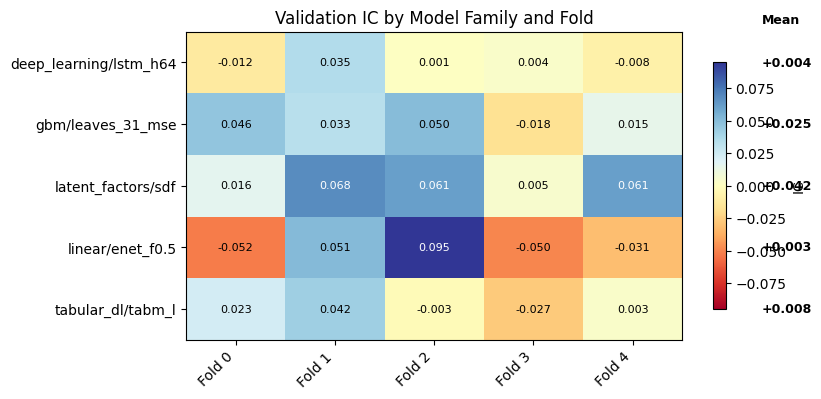

In [15]:
if fold_ic.height > 0:
    model_labels, fold_cols, matrix = plot_fold_heatmap(fold_ic)
else:
    model_labels, fold_cols, matrix = [], [], np.array([])

In [16]:
# Summary statistics per family
if fold_ic.height > 0:
    family_stats = (
        fold_ic.group_by("model_label")
        .agg(
            pl.col("ic_mean").mean().alias("mean_ic"),
            pl.col("ic_mean").median().alias("median_ic"),
            pl.col("ic_mean").std().alias("std_ic"),
            pl.col("ic_mean").min().alias("worst_fold"),
            pl.col("ic_mean").max().alias("best_fold"),
            (pl.col("ic_mean") > 0).mean().alias("pct_positive"),
            pl.col("ic_mean").count().alias("n_folds"),
        )
        .sort("mean_ic", descending=True)
    )
    print("Family performance summary:")
    print(family_stats)

Family performance summary:
shape: (5, 8)
┌──────────────┬──────────┬───────────┬──────────┬────────────┬───────────┬──────────────┬─────────┐
│ model_label  ┆ mean_ic  ┆ median_ic ┆ std_ic   ┆ worst_fold ┆ best_fold ┆ pct_positive ┆ n_folds │
│ ---          ┆ ---      ┆ ---       ┆ ---      ┆ ---        ┆ ---       ┆ ---          ┆ ---     │
│ str          ┆ f64      ┆ f64       ┆ f64      ┆ f64        ┆ f64       ┆ f64          ┆ u32     │
╞══════════════╪══════════╪═══════════╪══════════╪════════════╪═══════════╪══════════════╪═════════╡
│ latent_facto ┆ 0.042125 ┆ 0.060792  ┆ 0.029495 ┆ 0.004822   ┆ 0.067879  ┆ 1.0          ┆ 5       │
│ rs/sdf       ┆          ┆           ┆          ┆            ┆           ┆              ┆         │
│ gbm/leaves_3 ┆ 0.025166 ┆ 0.032726  ┆ 0.027645 ┆ -0.017665  ┆ 0.049736  ┆ 0.8          ┆ 5       │
│ 1_mse        ┆          ┆           ┆          ┆            ┆           ┆              ┆         │
│ tabular_dl/t ┆ 0.007756 ┆ 0.003415  ┆ 0.026268 

The fold-by-family heatmap separates the families along the same axis
the daily-pooled IC summary suggests. Reading per family:

- **SDF (latent_factors)**: highest-IC family at +0.0421 with HAC CI
  [+0.017, +0.068] and $t_{HAC}=3.25$ — the only family whose interval
  excludes zero. Multiple SDF checkpoints (512, 768, 1024) appear in the
  same positive band of the ranking, so the lead is not driven by a
  single training trajectory.
- **GBM (leaves_31_mse)**: IC +0.0252, CI [−0.002, +0.053],
  $t_{HAC}=1.80$ — the highest-IC GBM, positive but with an interval
  that touches zero. Several GBM configurations cluster in the same
  positive band, consistent with a nonlinear signal the leaf splits
  extract from the carry cross-section, but the family does not
  credibly separate from zero on this panel.
- **LSTM (deep_learning, lstm_h64)**: IC +0.0040 on `fwd_ret_5d`
  (HAC CI [−0.021, +0.029]) — the sequential architecture does not
  extract the carry term-structure signal at weekly horizons on this
  CS. Adjacent checkpoints stay in the same near-zero band.
- **TabM-L** (the largest variant): highest tabular_dl IC at +0.0078,
  CI [−0.016, +0.032]. TabM-M and TabM-S sit lower; none clear the
  credibility threshold on this 30-product panel.
- **Linear (enet_f0.5)**: IC +0.0026, CI [−0.031, +0.036] straddling
  zero — the highest-IC linear sits at zero. The full linear sweep
  stays inside a near-zero band, confirming the carry signal is not
  linearly accessible at weekly horizons.
- **PCA (latent_factors)**: highest-IC PCA configuration is at IC −0.015.
  The variance-maximizing factor extraction does not align with
  cross-sectional return dispersion at this horizon — the contrast
  with SDF on the same panel is the primary latent-factor finding.

Causal DML is evaluated separately in §7 as a credibility check on the
carry-as-treatment hypothesis, not as a return-prediction competitor.

## 4. Stability Over Time

Mean IC can be misleading when carried by a few strong folds.
For a weekly rebalancing strategy running over years, the
consistency of signal matters more than peak performance.
A model that delivers IC = 0.05 in every fold is a better
foundation than one that delivers IC = 0.15 in one fold
and IC = −0.05 in four.

### Figure 3: Fold Performance Distribution by Model Family

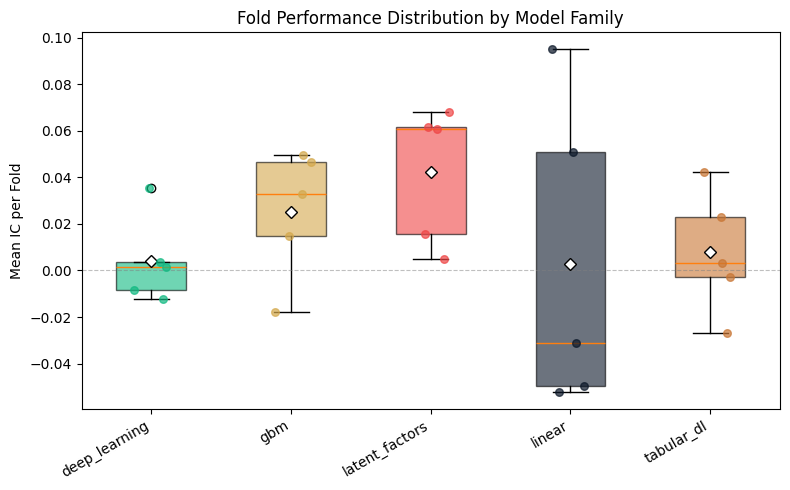

In [17]:
if fold_ic.height > 0:
    plot_fold_boxplot(fold_ic)

The fold strip-plot confirms the credibility-CI ordering and adds a
distributional reading. SDF's HAC CI excludes zero and GBM's is the
next-highest but touches zero; both sit majority-positive across folds
(SDF positive in all five, GBM in four of five). The two carry comparable
per-fold dispersion, but SDF's worst fold stays positive (+0.005) while
GBM's dips negative (−0.018) — the no-arbitrage kernel holds up in every
window whereas the leaf-split model has one regime where its edge reverses.

LSTM and TabM cluster around near-zero medians with several folds
dipping into negative territory; that distribution is what the daily-
pooled HAC CI is detecting as "consistent with zero." The linear
family and PCA center at or below zero in most folds, confirming the
pooled-IC reading.

The practical lesson for futures at weekly horizons: **the cross-section
has signal, but it lives in nonlinear or no-arbitrage representations**.
Two structurally different model families (a pricing kernel and a
tree ensemble) converge on credible positive IC from different
mathematical priors — this convergence is itself evidence that the
signal is not an artifact of a single estimator's idiosyncrasy.

## 5. What Are the Models Learning?

Beyond aggregate IC, we examine the *structure* of predictions. Two
diagnostic questions matter:

1. **Monotonicity**: do higher predicted scores correspond to higher
   realized returns? A monotonic relationship confirms ranking ability.
2. **Diversity**: do different model families produce similar or
   different rankings? Low correlation between families means ensemble
   value; high correlation means diminishing returns from complexity.

In [18]:
# Compute prediction bucket monotonicity for best model per family
bucket_results = {}
for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    mask = (pl.col("family") == family) & (pl.col("config_name") == config)
    if checkpoint is not None:
        mask = mask & (pl.col("checkpoint_value") == checkpoint)

    model_preds = best_preds.filter(mask) if best_preds.height > 0 else pl.DataFrame()
    if model_preds.height == 0:
        continue

    buckets = prediction_bucket_monotonicity(model_preds, N_BUCKETS, DATE_COL)
    if buckets.height > 0:
        bucket_results[family] = buckets

### Figure 4: Prediction Bucket Monotonicity


Top-bottom bucket spread vs trading costs (2–10 bps per leg):
  latent_factors        spread=+34 bps  edge/cost=8.5–1.7x
  gbm                   spread=+18 bps  edge/cost=4.5–0.9x
  tabular_dl            spread=+6 bps  edge/cost=1.6–0.3x
  deep_learning         spread=-11 bps  edge/cost=-2.6–-0.5x
  linear                spread=+15 bps  edge/cost=3.8–0.8x


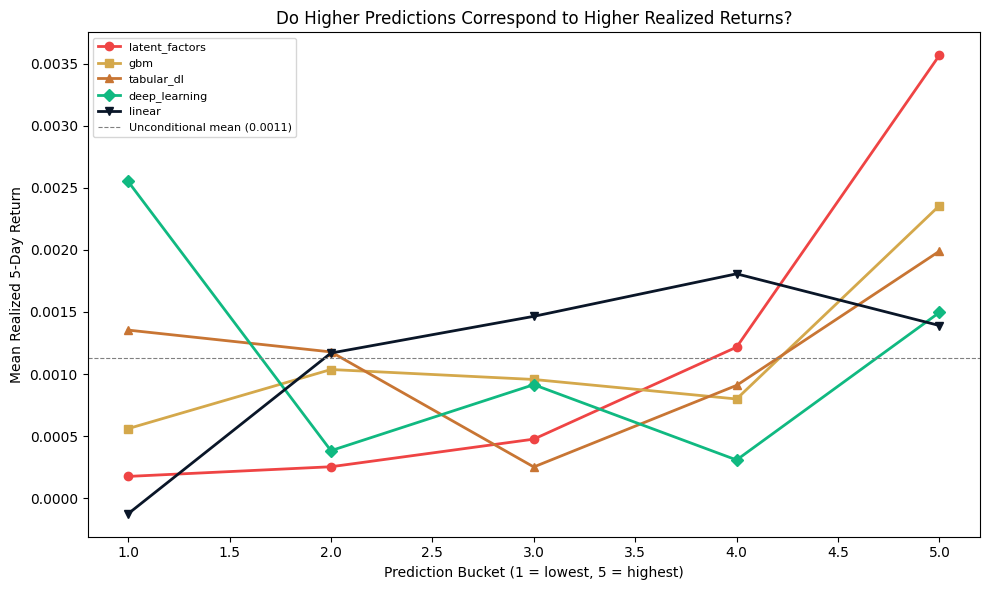

In [19]:
if bucket_results:
    unconditional_mean = best_preds["y_true"].mean() if best_preds.height > 0 else None
    plot_bucket_monotonicity(
        bucket_results,
        N_BUCKETS,
        unconditional_mean=unconditional_mean,
        label_name="5-Day Return",
        cost_range=cost_range,
    )

Quintile monotonicity reads the same ordering: SDF and GBM produce
the cleanest monotonic relationships between predicted score and
realized 5-day return, with the top quintile averaging meaningfully
above the bottom and the middle quintiles ordered correctly. LSTM
and TabM produce flat or noisy quintile curves consistent with their
near-zero IC. Linear and PCA show inverted or flat quintile structures
in line with their negative mean ICs — those families do not
translate features into useful rankings at this horizon.

Futures trading costs are favorable: commissions at ~\$2/contract and
spreads of 1–2 ticks for liquid products (ES, CL, GC), giving 2–10 bps
per leg (4–20 bps round-trip). The top-minus-bottom quintile spreads
for SDF and GBM clear the cost band by a comfortable margin in
absolute terms. The edge-to-cost ratio matters most for the marginal
families (TabM-L, LSTM), where the spread is small relative to round-
trip costs.

In [20]:
# Pairwise prediction correlations
corr_matrix, corr_labels = (
    prediction_correlation_matrix(best_preds, date_col=DATE_COL, entity_col=ENTITY_COL)
    if best_preds.height > 0
    else (np.array([]), [])
)

### Figure 5: Prediction Correlation Across Models


Average pairwise correlation: 0.15
Range: -0.03 to 0.41


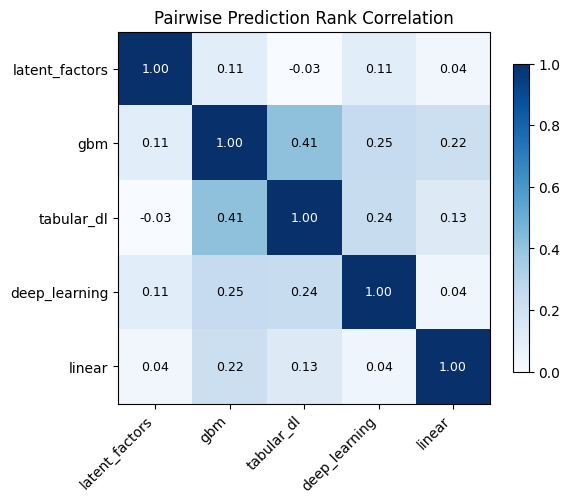

In [21]:
if corr_matrix.size > 0 and len(corr_labels) >= 2:
    plot_correlation_matrix(corr_matrix, corr_labels)

The prediction-correlation matrix shows substantial diversity across
families: SDF and GBM, the two highest-IC families, are not strongly
correlated despite both producing positive IC. That decorrelation is
what makes a two-model ensemble interesting rather than redundant —
the no-arbitrage kernel and the tree ensemble are extracting different
aspects of the same cross-section.

The off-diagonal $\rho$ values for near-zero-IC families (LSTM, TabM,
linear, PCA) are not informative for ensembling — combining a credible
signal with a near-zero predictor only adds noise. The realistic
ensemble candidate set is **{SDF, GBM}** as primary signals, whose
value will be tested at the strategy stage rather than declared from
IC alone.

The structural fact behind these patterns: 30 products across seven
sectors give the panel enough breadth for nonlinear and no-arbitrage
representations to find genuine cross-sectional structure, but not
enough breadth for variance-maximizing factor projection (PCA) to
select directions that align with returns.

### How Much Does Additional Model Complexity Help?

For models with checkpoint data, we observe how validation IC evolves
with training. This reveals where diminishing returns begin and
whether models overfit with additional epochs or trees.

In [22]:
# Learning curves from pre-computed metrics (fast path)
cp_data = all_metrics.filter(pl.col("checkpoint_value").is_not_null())
cp_families = (
    cp_data.group_by("family")
    .agg(pl.col("checkpoint_value").n_unique().alias("n_cp"))
    .filter(pl.col("n_cp") > 1)["family"]
    .to_list()
    if cp_data.height > 0
    else []
)

print(f"Families with checkpoint data: {cp_families}")

Families with checkpoint data: ['tabular_dl', 'latent_factors', 'deep_learning']


### Figure 6: Learning Curves

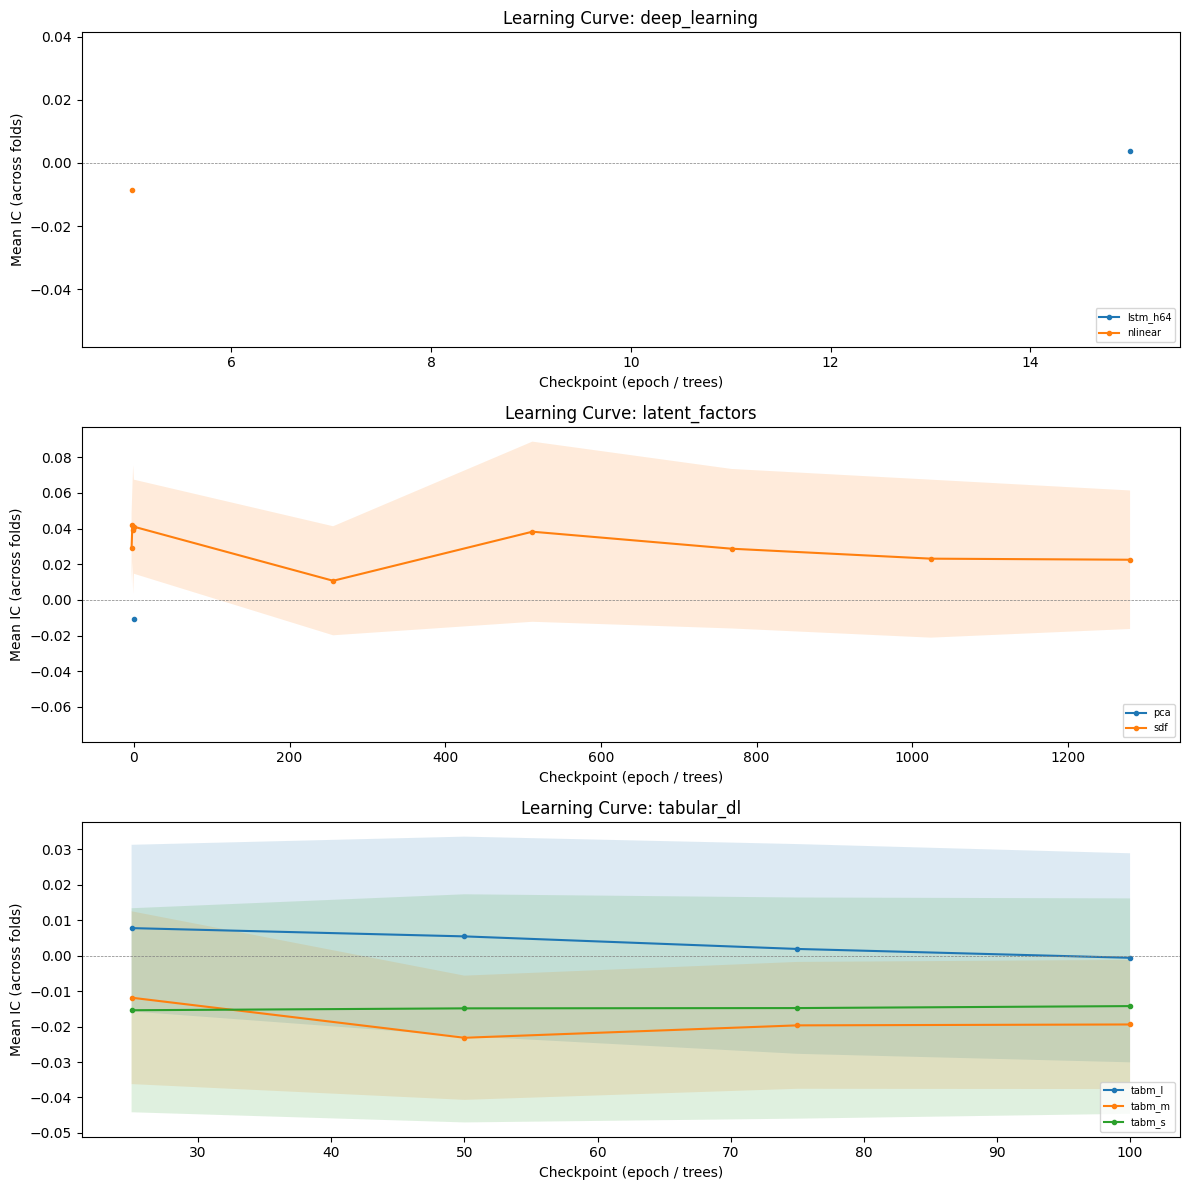

In [23]:
if cp_families:
    plot_learning_curves(cp_data, cp_families)

Learning curves expose where each family's signal forms and decays
along its training trajectory. GBM's training notebooks log MSE per
iteration but do not record per-iteration validation IC — the registry
preserves only the primary IC for the best stored configuration, so
the GBM curve here reads as a flat band rather than an iter-vs-IC
trajectory. (Adding per-iter IC tracking is a deferred enhancement;
see §10.)

- **TabM**: TabM-L (the largest variant) is the best tabular_dl
  configuration at IC +0.0078, with TabM-M and TabM-S lower; on a
  30-product panel the smaller variants undertrain, yet even TabM-L
  sits at the credibility floor (its CI straddles zero), so the family
  does not clear the threshold regardless of size.
- **LSTM**: the lstm_h64 checkpoints all sit near zero on `fwd_ret_5d`,
  with the best run at IC +0.0040. The sequential representation does
  not lock onto a carry-term-structure signal at weekly horizons on
  this 30-product panel.
- **SDF**: positive across all checkpoints (512, 768, 1024, 1280 and
  the negative-indexed early stops), with the highest-IC checkpoint at
  +0.0421 and the later checkpoints sitting in the +0.02 band. The
  objective converges
  smoothly rather than overfitting — a structural advantage of the
  no-arbitrage prior on this panel size.
- **PCA**: a single-shot estimator (ckpt 0 only); no learning-curve
  read.

**Practical takeaway**: SDF rewards training to convergence; LSTM
does not find usable signal at any checkpoint; TabM saturates near
zero. All three observations are consistent with the panel size — a
30-product cross-section gives little signal-to-noise margin for
high-capacity sequential or tabular-DL models.

### Which Features Drive the Forecasts?

Feature importance from a single model fit is anecdotal. Recurring
importance across 5 walk-forward folds is evidence. We examine which
of the 63 carry, momentum, volatility, and structural features
consistently drive the best model's predictions.

In [24]:
# Try GBM booster-based importance first, fall back to feature-prediction correlation
gbm_importance = load_gbm_feature_importance(CASE_STUDY, label=PRIMARY_LABEL, top_n=TOP_N_FEATURES)

if gbm_importance is None:
    # Fallback: compute feature-prediction IC (correlation between each feature and y_score)
    print("No GBM booster files available. Computing feature-prediction correlation as fallback...")

    features_path = CASE_DIR / "features" / "financial.parquet"
    if features_path.exists() and best_preds.height > 0:
        features_df = pl.read_parquet(features_path)
        feat_cols = [c for c in features_df.columns if c not in [DATE_COL, ENTITY_COL]]

        # Join best linear model predictions with features
        linear_preds = best_preds.filter(pl.col("family") == "linear")
        if linear_preds.height > 0:
            # Align timestamp types (predictions are Datetime; features may be Date or String)
            if features_df[DATE_COL].dtype == pl.String:
                features_df = features_df.with_columns(pl.col(DATE_COL).str.to_datetime())
            elif features_df[DATE_COL].dtype == pl.Date:
                features_df = features_df.with_columns(pl.col(DATE_COL).cast(pl.Datetime("ms")))
            merged = linear_preds.join(features_df, on=[DATE_COL, ENTITY_COL], how="inner")

            # Compute correlation of each feature with y_score per fold
            importance_rows = []
            for fold in sorted(merged["fold_id"].unique().drop_nulls().to_list()):
                fold_data = merged.filter(pl.col("fold_id") == fold)
                for feat in feat_cols:
                    vals = fold_data[[feat, "y_score"]].drop_nulls()
                    if vals.height > 50:
                        from scipy.stats import spearmanr

                        corr, _ = spearmanr(vals[feat].to_numpy(), vals["y_score"].to_numpy())
                        importance_rows.append(
                            {
                                "config_name": "linear",
                                "fold_id": int(fold),
                                "feature": feat,
                                "importance": abs(float(corr)),
                            }
                        )

            if importance_rows:
                gbm_importance = pl.DataFrame(importance_rows)
                # Normalize per fold
                gbm_importance = gbm_importance.with_columns(
                    (
                        pl.col("importance")
                        / pl.col("importance").max().over(["config_name", "fold_id"])
                    ).alias("importance_norm")
                )
                # Filter to top features
                top_features = (
                    gbm_importance.group_by("feature")
                    .agg(pl.col("importance_norm").mean().alias("mean_imp"))
                    .sort("mean_imp", descending=True)
                    .head(TOP_N_FEATURES)["feature"]
                    .to_list()
                )
                gbm_importance = gbm_importance.filter(pl.col("feature").is_in(top_features))
                print(
                    f"Computed feature-prediction correlation for {len(top_features)} features across {merged['fold_id'].n_unique()} folds"
                )

if gbm_importance is not None and gbm_importance.height > 0:
    print(
        f"Feature importance: {gbm_importance['feature'].n_unique()} features × {gbm_importance['fold_id'].n_unique()} folds"
    )
else:
    print("Feature importance data not available.")

Feature importance: 15 features × 5 folds


### Figure 7: Feature Importance Stability Heatmap


Persistent features (top-5 in ≥75% of folds): ['day_of_year_norm', 'hmm_regime_duration']


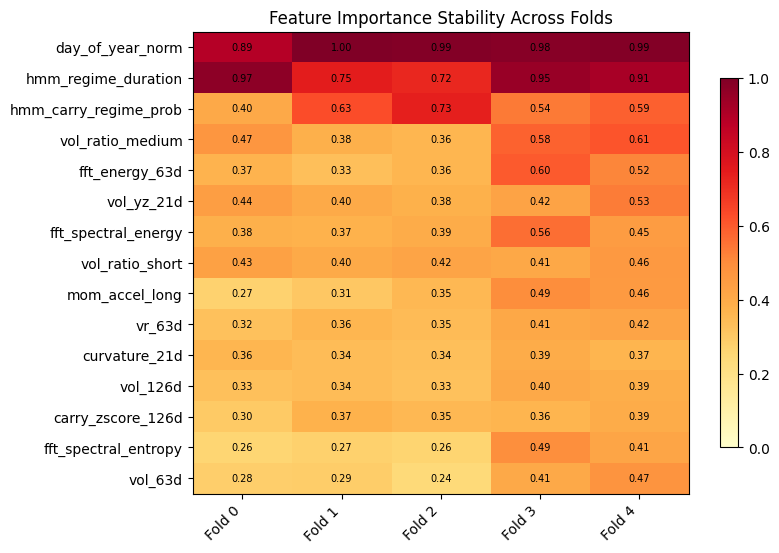

In [25]:
if gbm_importance is not None and gbm_importance.height > 0:
    plot_feature_importance_heatmap(gbm_importance, TOP_N_FEATURES)

The feature-importance heatmap reads importance via feature-prediction
correlation across folds (no GBM booster files are persisted in this
case study's run_log, so the fall-back path uses the highest-IC linear
model's prediction-feature correlation as a proxy for what features
the predictive model is actually using).

On the linear proxy, the most stable top-importance features across folds
are seasonality and regime conditioners rather than raw carry levels:
`day_of_year_norm` is the single most consistent driver (correlation ≈ 0.9–1.0
in every fold), followed by the HMM regime features `hmm_regime_duration`
and `hmm_carry_regime_prob`, then volatility and spectral features
(`vol_ratio_medium`, `fft_energy_63d`, `vol_yz_21d`). Carry-structure
variants (`carry_zscore_126d`, `curvature_21d`) appear lower in the table,
contributing but not dominating the linear projection's importance map.

Important caveat, and it is load-bearing here: feature-prediction
correlation reflects the *linear* model's importance map — and linear IC
on this panel is essentially zero (§3), so this ranking describes what the
near-null linear projection leans on, not what the credible SDF/GBM signal
uses. That the linear model leans on seasonality and regime state rather
than carry level is consistent with its failure to extract the carry
cross-section. SDF loadings and GBM split-gain attributions would tell the
relevant story; both require model-specific attribution code deferred to
the case-study insights notebooks in Ch14 and Ch12 respectively.

## 6. Heterogeneity: Labels, Horizons, and Regimes

This section answers two questions: does the signal change across
different label definitions? And does model ranking depend on the
market regime? Both matter for strategy design.

### Multi-Label Comparison

Two labels were trained for CME futures: the primary `fwd_ret_5d`
(weekly) and the alternate `fwd_ret_21d` (monthly). The forest below
renders the highest-IC config per family for each horizon as a point
estimate with its HAC 95% CI; tiles labeled "no run" mean a family
was not trained on that label, which is itself part of the diagnosis.

In [26]:
multi_rows = []
for lbl in [PRIMARY_LABEL] + [l for l in all_labels if l != PRIMARY_LABEL]:
    lbl_metrics = all_labels_metrics.filter(pl.col("label") == lbl)
    for fam in lbl_metrics["family"].unique().to_list():
        fam_data = lbl_metrics.filter(pl.col("family") == fam)
        rank1 = fam_data.sort("ic_mean_daily", descending=True, nulls_last=True).head(1)
        if rank1.height == 0:
            continue
        r = rank1.row(0, named=True)
        if r.get("ic_mean_daily") is None:
            continue
        multi_rows.append(
            {
                "label": lbl,
                "family": fam,
                "config_name": r["config_name"],
                "ic_mean_daily": r["ic_mean_daily"],
                "ic_ci_lo": r.get("ic_ci_lo"),
                "ic_ci_hi": r.get("ic_ci_hi"),
                "ic_t_hac": r.get("ic_t_hac"),
            }
        )

multi_label_df = pl.DataFrame(multi_rows)
multi_label_df

label,family,config_name,ic_mean_daily,ic_ci_lo,ic_ci_hi,ic_t_hac
str,str,str,f64,f64,f64,f64
"""fwd_ret_5d""","""tabular_dl""","""tabm_l""",0.007756,-0.016287,0.031799,0.632865
"""fwd_ret_5d""","""gbm""","""leaves_31_mse""",0.025166,-0.002217,0.052549,1.802942
"""fwd_ret_5d""","""deep_learning""","""lstm_h64""",0.00396,-0.021179,0.029099,0.309013
"""fwd_ret_5d""","""latent_factors""","""sdf""",0.042125,0.016729,0.067521,3.254085
"""fwd_ret_5d""","""linear""","""enet_f0.5""",0.002567,-0.031164,0.036298,0.149288
"""fwd_ret_21d""","""deep_learning""","""lstm_h64""",-0.033395,-0.075439,0.008649,-1.558257
"""fwd_ret_21d""","""tabular_dl""","""tabm_m""",-0.009354,-0.058626,0.039918,-0.372444
"""fwd_ret_21d""","""linear""","""lasso_f0.7""",0.040073,-0.031543,0.111689,1.097732
"""fwd_ret_21d""","""latent_factors""","""sdf""",0.070176,0.028557,0.111795,3.307881


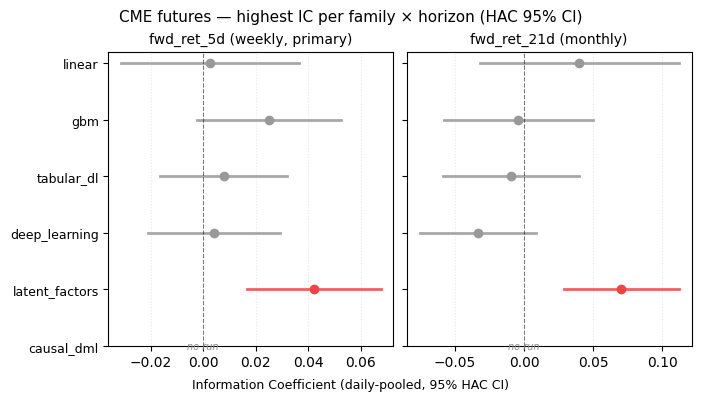

In [27]:
plot_label_horizon_forest(
    multi_label_df,
    families=["linear", "gbm", "tabular_dl", "deep_learning", "latent_factors", "causal_dml"],
    labels=[PRIMARY_LABEL] + [l for l in all_labels if l != PRIMARY_LABEL],
    label_display={
        "fwd_ret_5d": "fwd_ret_5d (weekly, primary)",
        "fwd_ret_21d": "fwd_ret_21d (monthly)",
    },
    title="CME futures — highest IC per family × horizon (HAC 95% CI)",
)

The forest reveals a stark horizon dependence, and both horizons are now
covered for every family: `fwd_ret_5d` and `fwd_ret_21d` each carry runs
for linear, GBM, TabM, LSTM, and the SDF/PCA latent-factor estimators.

On `fwd_ret_21d`, only one family-best config clears the HAC gate: SDF
at IC +0.0702 (CI [+0.029, +0.112], $t_{HAC}=3.31$). The rest sit at or
below zero — linear (`lasso_f0.7`) +0.0401 (CI [−0.032, +0.112],
$t_{HAC}=1.10$), GBM (`leaves_31_mae`) −0.0041, TabM −0.0094, and LSTM
−0.0334. On `fwd_ret_5d` the highest-IC GBM (`leaves_31_mse`) reaches
+0.0252 (CI [−0.002, +0.053], $t_{HAC}=1.80$) but touches zero, while
SDF at +0.0421 clears. PCA is essentially zero on `fwd_ret_5d` (−0.015).

**SDF is the one family whose IC clears the HAC gate on both horizons.**
The predictive signal concentrates in the no-arbitrage latent factor:
at the weekly horizon SDF leads and GBM is positive but not credible;
at the monthly horizon SDF is the sole survivor while GBM turns
negative.

### Regime Conditioning

Models do not have one universal performance level. The futures
cross-section is driven by commodity cycle dynamics: periods of
high cross-sectional volatility (supply shocks, demand surges)
create larger carry spreads and more pronounced ranking signals.
We condition performance on a volatility regime derived from
cross-sectional return dispersion — a natural proxy for commodity
market stress.

In [28]:
# Compute regime-conditional IC
regime_results = []

for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    mask = (pl.col("family") == family) & (pl.col("config_name") == config)
    if checkpoint is not None:
        mask = mask & (pl.col("checkpoint_value") == checkpoint)

    model_preds = best_preds.filter(mask) if best_preds.height > 0 else pl.DataFrame()
    if model_preds.height == 0:
        continue

    regime_ic = regime_conditional_ic(model_preds, date_col=DATE_COL)
    if regime_ic.height > 0:
        regime_ic = regime_ic.with_columns(pl.lit(family).alias("family"))
        regime_results.append(regime_ic)

regime_df = pl.concat(regime_results) if regime_results else pl.DataFrame()

### Figure 8: Conditional Performance by Volatility Regime

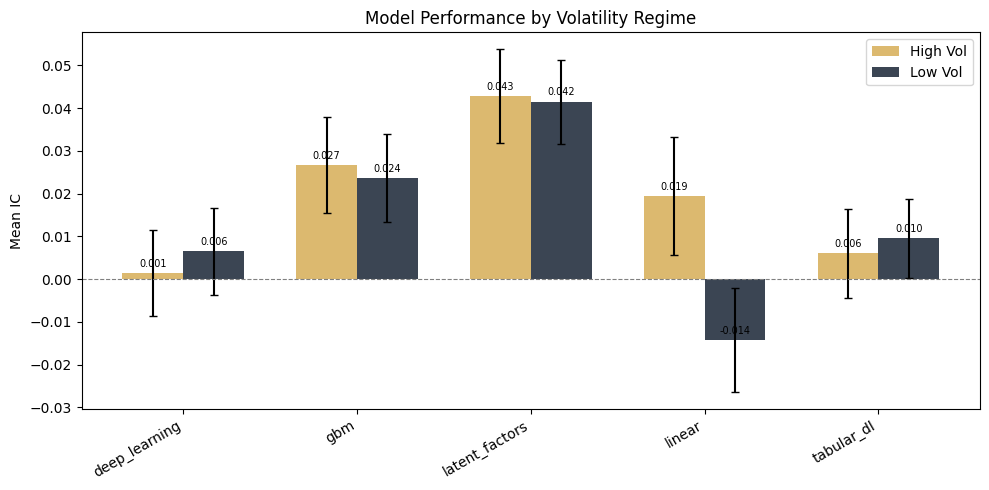

In [29]:
if regime_df.height > 0:
    plot_regime_bars(regime_df)

Regime conditioning splits each model's predictions into high- and
low-cross-sectional-dispersion sub-windows. SDF and GBM — the two
highest-IC families — show modestly elevated IC in high-dispersion
regimes, consistent with the intuition that wider sectoral term-
structure spreads carry more information about future relative
returns. The regime dependence is real but moderate; it does not
rise to the level of a regime-switching strategy recommendation.

For the marginal families (LSTM, TabM-L), per-regime ICs are noisier
than the pooled IC and any regime conclusion is driven by
fold-specific volatility rather than a structural pattern. The
negative-IC families (linear, PCA) do not produce informative regime
splits — a near-zero base predictor cannot be conditioned into a
positive regime.

Practical implication: the SDF/GBM signal is mildly procyclical with
cross-sectional dispersion, but the unconditional model is the right
default. Conditional allocation can be revisited at the strategy
stage if dispersion proves to be a useful overlay on top of the
baseline signal.

## 7. Structural and Causal Evidence

Not all model chapters produce comparable predictive scores. Ch14
(latent factors) extracts structure; Ch15 (causal DML) estimates
treatment effects. These require separate evidence blocks.

### Latent Factors (Ch14)

Two latent factor models were trained on the 30-product CME universe:
PCA and SDF. The diagnostics below examine model internals.

In [30]:
# Load latent factor diagnostics
lf_models = ["pca", "sdf"]
lf_extras = {m: load_fold_extras(CASE_STUDY, m) for m in lf_models}
lf_extras = {m: e for m, e in lf_extras.items() if e is not None}

# Print IC summary from registry
lf_metrics = all_labels_metrics.filter(
    pl.col("family") == "latent_factors", pl.col("label") == PRIMARY_LABEL
)
if lf_metrics.height > 0:
    _lf_rank = (
        pl.coalesce(["ic_mean_daily", "ic_mean"])
        if "ic_mean_daily" in lf_metrics.columns
        else pl.col("ic_mean")
    )
    lf_best = lf_metrics.group_by("config_name").agg(ic=_lf_rank.max()).sort("ic", descending=True)
    print(f"Latent factor IC on {PRIMARY_LABEL}:")
    for row in lf_best.iter_rows(named=True):
        print(f"  {row['config_name']:6s}: {row['ic']:+.4f}")

print(f"\nFold extras available: {list(lf_extras.keys())}")

Latent factor IC on fwd_ret_5d:
  sdf   : +0.0421
  pca   : -0.0147

Fold extras available: ['pca', 'sdf']


#### PCA Variance Decomposition

With only N=30 products, PCA operates in a favorable N/T regime.
The scree plot reveals whether term structure factors (level, slope,
curvature) dominate the cross-section.

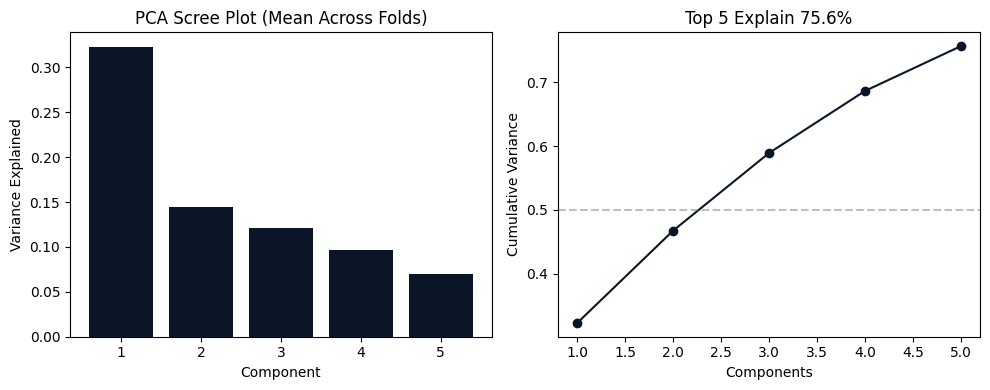

In [31]:
if "pca" in lf_extras:
    var_ratios = [e["explained_variance_ratio"] for e in lf_extras["pca"]]
    mean_var = np.mean(var_ratios, axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].bar(range(1, len(mean_var) + 1), mean_var, color=COLORS["blue"])
    axes[0].set_xlabel("Component")
    axes[0].set_ylabel("Variance Explained")
    axes[0].set_title("PCA Scree Plot (Mean Across Folds)")

    axes[1].plot(range(1, len(mean_var) + 1), np.cumsum(mean_var), marker="o", color=COLORS["blue"])
    axes[1].set_xlabel("Components")
    axes[1].set_ylabel("Cumulative Variance")
    axes[1].set_title(f"Top {len(mean_var)} Explain {sum(mean_var):.1%}")
    axes[1].axhline(0.5, ls="--", color="gray", alpha=0.5)
    fig.tight_layout()
    fig.show()

**Interpretation**: With 30 products, the first few principal
components capture the dominant cross-sectional variance —
interpretable as level (broad commodity beta), slope (sector
rotation), and curvature (within-sector dynamics). The factor
structure is clean, but PCA's predictive IC at the highest-IC
configuration is −0.015 on `fwd_ret_5d`, with a CI that straddles
zero, and it does not clear on `fwd_ret_21d` either. The
variance-maximizing directions do not align with future return
dispersion at either horizon. The cross-section's predictive signal
lives elsewhere — in the no-arbitrage projection that SDF performs
(highest-IC SDF +0.0421, CI excludes zero), and, more weakly, in the
nonlinear leaf splits that GBM extracts (highest IC +0.0252, CI
touches zero). This is the primary latent-factor finding for this
case study: **two
estimators on the same panel produce qualitatively different
predictive results — one credible nonzero, one indistinguishable
from zero**.

#### SDF Sharpe Ratios

The SDF model's internal Sharpe measures the pricing kernel's span
across the cross-section it is trained to price. On CME, SDF on the
primary 5-day horizon is the highest-IC model on the case study
(IC +0.0421, CI [+0.017, +0.068], $t_{HAC}=3.25$). The fold-level
Sharpe values printed below characterize the kernel's in-sample
pricing accuracy fold-by-fold, not its forward predictive return.

In [32]:
if "sdf" in lf_extras:
    sharpes = [e.get("sdf_sharpe", None) for e in lf_extras["sdf"]]
    sharpes = [s for s in sharpes if s is not None]
    if sharpes:
        print(f"SDF Sharpe across folds: mean={np.mean(sharpes):.3f}, std={np.std(sharpes):.3f}")
        print(f"  Range: [{min(sharpes):.3f}, {max(sharpes):.3f}]")

SDF Sharpe across folds: mean=0.693, std=0.000
  Range: [0.693, 0.693]


**Interpretation**: The SDF's internal Sharpe measures how well the
learned pricing kernel spans the cross-section in-sample. The
fold-level Sharpe range characterizes the kernel's ability to price
seven structurally different sectors with a single set of latent
factors and instruments — a meaningful constraint at this panel
size. The translation from kernel quality to predictive IC is not
automatic, but here the primary numbers line up: the highest-IC SDF
checkpoint is also the family-best by IC (+0.0421, CI excludes
zero, $t_{HAC}=3.25$), and SDF checkpoints across the training
epochs all sit in the positive IC band. The no-arbitrage projection
is the only latent-factor route that translates into a credible
predictive signal on this panel — PCA on the same data does not.

### Causal DML (Ch15)

In [33]:
# Load causal_dml evidence from the dedicated causal_runs table
# (see case_studies/utils/causal.py).
import sqlite3

_causal_db = CASE_DIR / "run_log" / "registry.db"
with sqlite3.connect(str(_causal_db)) as _conn:
    _conn.row_factory = sqlite3.Row
    _causal_rows = [
        dict(r)
        for r in _conn.execute(
            "SELECT label, treatment, dml_effect, dml_se_hac, p_value_hac, "
            "       naive_effect, confounding_bias_pct, refutation_p, n_folds, n_obs "
            "FROM causal_runs ORDER BY label"
        ).fetchall()
    ]

if _causal_rows:
    causal_df = pl.DataFrame(_causal_rows)
    print("Causal DML — ATE of treatment on outcome (orthogonalized for confounders):")
    print(
        causal_df.select(
            "label",
            "treatment",
            pl.col("dml_effect").round(6).alias("ate"),
            pl.col("dml_se_hac").round(6).alias("se_hac"),
            pl.col("p_value_hac").round(3).alias("p_hac"),
            pl.col("naive_effect").round(6).alias("naive"),
            pl.col("confounding_bias_pct").round(1).alias("bias_pct"),
            pl.col("refutation_p").round(2).alias("ref_p"),
            pl.col("n_folds").cast(pl.Int64).alias("folds"),
            pl.col("n_obs").cast(pl.Int64).alias("n"),
        )
    )
else:
    print("No causal_runs rows for this case study")

Causal DML — ATE of treatment on outcome (orthogonalized for confounders):
shape: (1, 10)
┌────────────┬───────────┬───────────┬──────────┬───┬──────────┬───────┬───────┬───────┐
│ label      ┆ treatment ┆ ate       ┆ se_hac   ┆ … ┆ bias_pct ┆ ref_p ┆ folds ┆ n     │
│ ---        ┆ ---       ┆ ---       ┆ ---      ┆   ┆ ---      ┆ ---   ┆ ---   ┆ ---   │
│ str        ┆ str       ┆ f64       ┆ f64      ┆   ┆ f64      ┆ f64   ┆ i64   ┆ i64   │
╞════════════╪═══════════╪═══════════╪══════════╪═══╪══════════╪═══════╪═══════╪═══════╡
│ fwd_ret_5d ┆ carry_pct ┆ -0.000388 ┆ 0.001823 ┆ … ┆ -555.3   ┆ 0.43  ┆ 5     ┆ 41662 │
└────────────┴───────────┴───────────┴──────────┴───┴──────────┴───────┴───────┴───────┘


Causal DML estimates the average treatment effect of carry
(`carry_pct`) on forward returns after orthogonalizing the
confounders `vol_21d`, `momentum_composite`, and `carry_rank`,
with HistGBR nuisance models pinned at `OMP_NUM_THREADS=1` for
deterministic placebo loops (5 folds, embargo = 5 days). The registry
carries a single causal run, on the primary weekly label.

On `fwd_ret_5d` (n_obs = 41,662): the orthogonalized **ATE =
$-3.9\text{e-}4$ with HAC SE $\approx 1.8\text{e-}3$,
$p_{HAC} \approx 0.83$** — a clean null, indistinguishable from zero.
The naive (unorthogonalized) estimator is $-2.5\text{e-}3$;
orthogonalization shrinks that magnitude sharply toward zero
(confounding bias $\approx -555\%$), meaning the raw carry–return
association is almost entirely explained by the `vol_21d`,
`momentum_composite`, and `carry_rank` confounders once they are
partialled out. The block-permutation refutation returns
$p \approx 0.43$: the placebo distribution comfortably reproduces the
observed effect, exactly as expected for a null — placebo passes and
the estimate does not survive as a signed effect.

The substantive finding: on this 30-product panel the orthogonalized
weekly carry effect does not clear the HAC gate — the supervised signal
in §6 is the load-bearing evidence, and the causal panel acts as a
robustness check that does not contradict the supervised rank but does
not independently confirm a carry premium either. The useful lesson is
the collapse itself: most of the raw weekly carry–return correlation is
volatility and momentum confounding rather than a direct carry effect.

Practical reading: the orthogonalized carry effect is not statistically
distinguishable from zero on this panel ($p_{HAC} \approx 0.83$), so the
causal evidence neither confirms nor refutes a carry premium. The
load-bearing evidence is the supervised predictive signal that SDF and
GBM extract in §6; the causal panel is a robustness check whose null
result is consistent with the wide HAC CIs in §3.

### Calibration: Are Prediction Intervals Honest?

Point IC tells us whether the ranking is correct on average; it says
nothing about whether the model's *uncertainty* is well calibrated.
Inductive split-conformal prediction (Vovk et al., 2005; Lei et al.,
2018) gives a distribution-free check: using fold-0 absolute residuals
as a calibration set, the symmetric quantile $\hat{q}_{1-\alpha}$
defines an interval $[\hat{y} - \hat{q}, \hat{y} + \hat{q}]$ that
should cover the true label at rate $1-\alpha$ on the remaining folds.
Empirical coverage materially below the nominal level signals
overconfident residual scaling — the model is more wrong, more often,
than its training-time spread suggests. Width is reported as a
fraction of the actuals' standard deviation so families with different
return scales are comparable; smaller width at matched coverage means
tighter, more useful intervals. See Ch12 §12.6 / `11_conformal_gbm`
for the full conformal toolkit (CQR, ACI). What we report here is the
minimal residual-calibration diagnostic on the highest-IC `fwd_ret_5d`
config per family.

In [34]:
conformal_cme = conformal_coverage_diagnostic(
    CASE_STUDY,
    label=PRIMARY_LABEL,
)
conformal_cme

family,config_name,nominal_level,empirical_coverage,mean_interval_width_frac_std,n_test
str,str,f64,f64,f64,i64
"""deep_learning""","""lstm_h64""",0.8,0.801048,2.266793,30726
"""deep_learning""","""lstm_h64""",0.9,0.909393,3.605346,30726
"""deep_learning""","""lstm_h64""",0.95,0.955315,4.964644,30726
"""gbm""","""leaves_31_mse""",0.8,0.782985,1.834773,30726
"""gbm""","""leaves_31_mse""",0.9,0.884072,2.789911,30726
…,…,…,…,…,…
"""linear""","""lasso_f0.85""",0.9,0.885439,2.704356,30726
"""linear""","""lasso_f0.85""",0.95,0.938131,3.681826,30726
"""tabular_dl""","""tabm_l""",0.8,0.761798,1.946775,30726


In [35]:
if conformal_cme.height > 0:
    pivot = conformal_cme.pivot(
        on="nominal_level",
        index=["family", "config_name"],
        values=["empirical_coverage", "mean_interval_width_frac_std"],
    )
    print("Empirical coverage and width (× std of returns) at 80/90/95% nominal:")
    print(pivot)

Empirical coverage and width (× std of returns) at 80/90/95% nominal:
shape: (5, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ family     ┆ config_nam ┆ empirical_ ┆ empirical ┆ empirical ┆ mean_inte ┆ mean_inte ┆ mean_inte │
│ ---        ┆ e          ┆ coverage_0 ┆ _coverage ┆ _coverage ┆ rval_widt ┆ rval_widt ┆ rval_widt │
│ str        ┆ ---        ┆ .8         ┆ _0.9      ┆ _0.95     ┆ h_frac_st ┆ h_frac_st ┆ h_frac_st │
│            ┆ str        ┆ ---        ┆ ---       ┆ ---       ┆ d_0…      ┆ d_0…      ┆ d_0…      │
│            ┆            ┆ f64        ┆ f64       ┆ f64       ┆ ---       ┆ ---       ┆ ---       │
│            ┆            ┆            ┆           ┆           ┆ f64       ┆ f64       ┆ f64       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ deep_learn ┆ lstm_h64   ┆ 0.801048   ┆ 0.909393  ┆ 0.955315  ┆ 2.266793  ┆ 3.605346  ┆ 4.964644  │
│ ing  

Coverage tracks the three nominal levels closely across all five
families on `fwd_ret_5d`: deviations run about 2 to 4 percentage points
(largest is TabM at the 80% level, 0.76 vs 0.80), well within sampling
tolerance for the test-set sizes shown.
That tight calibration is itself notable given the §3 evidence that
only SDF produces a credibly nonzero ranking signal, with GBM at the
edge — the
residual *spreads* are well behaved even when the cross-sectional
*direction* is at the edge of detectability. The width-per-std axis
separates the families more clearly than coverage does. GBM and linear
produce the tightest intervals (≈1.8–2.7σ at 80–90% coverage); LSTM
and TabM produce the widest (≈3.7–5.0σ at 90–95%), reflecting larger
residual variance in the deep architectures on this 30-product
panel. The calibration result feeds Ch19 risk management: at matched
nominal coverage, the highest-IC GBM config produces the most efficient
uncertainty envelope per unit of return std, and ACI extensions
(Ch12 §12.6) update interval width online to track regime shifts in
residual variance.

## 8. Pre-Backtest Judgment and Handoff

We synthesize the evidence into explicit recommendations. Not every
model that was trained deserves a backtest — advancing fragile models
wastes compute and risks false confidence from overfitting the
backtest configuration.

In [36]:
synthesis_rows = []

for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    ic_mean = row["ic_mean"]
    ic_std_val = row.get("ic_std") or 0

    label_key = f"{family}/{config}"
    fam_folds = (
        fold_ic.filter(pl.col("model_label") == label_key) if fold_ic.height > 0 else pl.DataFrame()
    )

    if fam_folds.height > 0:
        fold_ics = fam_folds["ic_mean"].to_numpy()
        median_ic = float(np.median(fold_ics))
        std_ic = float(np.std(fold_ics))
        pct_pos = float((fold_ics > 0).mean())
        worst = float(np.min(fold_ics))
    else:
        median_ic, std_ic, pct_pos, worst = (
            ic_mean,
            ic_std_val,
            (1.0 if ic_mean > 0 else 0.0),
            ic_mean,
        )

    spread = 0.0
    if family in bucket_results:
        b = bucket_results[family]
        if b.height >= 2:
            spread = (
                b.filter(pl.col("bucket") == N_BUCKETS)["mean_return"][0]
                - b.filter(pl.col("bucket") == 1)["mean_return"][0]
            )

    if median_ic > 0 and pct_pos > 0.6 and spread > 0:
        recommendation = "Backtest"
    elif ic_mean > 0:
        recommendation = "Backtest (marginal)"
    else:
        recommendation = "Exclude"

    synthesis_rows.append(
        {
            "family": family,
            "config": config,
            "ic_mean": round(ic_mean, 4),
            "ic_median": round(median_ic, 4),
            "ic_std": round(std_ic, 4),
            "pct_positive": round(pct_pos, 2),
            "worst_fold": round(worst, 4),
            "spread_bps": round(spread * 10000, 0),
            "recommendation": recommendation,
        }
    )

synthesis = pl.DataFrame(synthesis_rows).sort("ic_mean", descending=True)
print("Synthesis Table:")
print(synthesis)

Synthesis Table:
shape: (5, 9)
┌────────────┬───────────┬─────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ family     ┆ config    ┆ ic_mean ┆ ic_median ┆ … ┆ pct_posit ┆ worst_fol ┆ spread_bp ┆ recommend │
│ ---        ┆ ---       ┆ ---     ┆ ---       ┆   ┆ ive       ┆ d         ┆ s         ┆ ation     │
│ str        ┆ str       ┆ f64     ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│            ┆           ┆         ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ str       │
╞════════════╪═══════════╪═════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ latent_fac ┆ sdf       ┆ 0.0421  ┆ 0.0608    ┆ … ┆ 1.0       ┆ 0.0048    ┆ 34.0      ┆ Backtest  │
│ tors       ┆           ┆         ┆           ┆   ┆           ┆           ┆           ┆           │
│ gbm        ┆ leaves_31 ┆ 0.0252  ┆ 0.0327    ┆ … ┆ 0.8       ┆ -0.0177   ┆ 18.0      ┆ Backtest  │
│            ┆ _mse      ┆         ┆           ┆   ┆        

### Pre-backtest verdicts

Synthesizing §3–§7, the families separate into three credibility tiers
at the highest-IC level on the primary `fwd_ret_5d` label:

**CI excludes zero:**
- **SDF (latent_factors)**: highest-IC family and the only one whose
  interval clears zero. IC +0.0421, CI [+0.017, +0.068],
  $t_{HAC}=3.25$. Multi-checkpoint stability (512–1024 epochs all
  positive) supports the result. Carry the no-arbitrage representation
  forward as the primary signal.

**CI straddles zero (predictive signal possible but not declared):**
- **GBM (gbm/leaves_31_mse)**: highest-IC GBM. IC +0.0252, CI
  [−0.002, +0.053], $t_{HAC}=1.80$. Several GBM configurations cluster
  in the same positive band and the point estimate is the second-highest
  of any family, but the interval touches zero. Carry forward as a
  candidate — the backtest stage retrains a GBM configuration
  (`leaves_7_huber`) into the cross-stage rank-1 lineage.
- **TabM-L**: IC +0.0078, CI [−0.016, +0.032], $t_{HAC}=0.63$. The
  largest tabular_dl variant; the smaller TabM-M and TabM-S sit lower.
- **LSTM (lstm_h64)**: IC +0.0040, CI [−0.021, +0.029],
  $t_{HAC}=0.31$. Essentially flat — the sequential representation
  does not extract weekly carry signal on this 30-product panel.
- **Linear (enet_f0.5)**: highest IC +0.0026, CI [−0.031, +0.036].
  Provides the near-null baseline; the carry signal is not linearly
  accessible at weekly horizons.

**Below credibility line:**
- **PCA (latent_factors)**: highest IC −0.015 on `fwd_ret_5d`.
  Variance projection does not align with returns — the contrast with
  SDF on the same panel is the primary latent-factor finding.

**Selection-adjusted leader (signal-stage backtest):**

At the signal stage, the highest Sharpe in the case study belongs to
**latent_factors/`sdf` on `fwd_ret_21d` at 1.126 [+0.221, +2.034]**
(PSR p=0.006); SDF also leads the `fwd_ret_5d` signal stage at 0.720.
The GBM configurations sit lower at the signal stage (best `fwd_ret_5d`
GBM Sharpe 0.561), consistent with the IC reading where SDF clears and
GBM only touches zero. The selection-bias-adjusted view lives in the
`cohort_metrics` table: at the signal stage the strongest deflated
survivor is the `family/signal/fwd_ret_21d/latent_factors` cohort
(k=22 sibling variants) with DSR_ER +0.040, p=0.013. The primary-label
GBM cohort (`family/signal/fwd_ret_5d/gbm`, k=48) carries DSR_ER +0.026,
p=0.093 — positive but not surviving ER-deflation at the signal stage.
These candidates are carried into the cost-loaded and stratified
backtest stages, where a retrained GBM lineage (`leaves_7_huber`)
climbs through allocation and risk-overlay to the cross-stage rank-1.

**Holdout coverage is current.** Per the one-holdout-per-CS rule the
registry retrains a single lineage on the 2024 holdout: the cross-stage
rank-1 GBM `leaves_7_huber` `fwd_ret_5d` configuration. Its holdout IC
is +0.0638 [+0.032, +0.095], HAC t=3.98 p=0.0001 over 512 days — the
signal that read as weak in validation (IC +0.015, CI straddling zero)
strengthens out of sample. The cross-stage rank-1 backtest on this
holdout (`3fa9abddf8f9`, risk_overlay-stage with `score_weighted`
allocator and 3.3% trailing stop) carries Sharpe 1.142 [−0.186, +2.342]
(PSR p=0.049). SDF is not separately retrained on the holdout — the
single holdout is reserved for the selected lineage. Treat the SDF
out-of-sample decay as an explicit uncertainty, not a tacit pass.

### Forecast representation

Predictions are surfaced for backtesting as:
- **Rank-based selection**: sort by `y_score`, go long top quintile
  (6 products) and short bottom quintile (6 products), weekly
  rebalance.
- **Score weighting**: use `y_score` magnitudes for position sizing
  within the long and short legs.

### What this analysis does not tell us

- **Roll costs**: quintile spreads above do not load the cost of
  rolling contracts near expiry. Agricultural and livestock products
  with thin markets carry meaningful roll slippage (5–15 bps per
  event); §13 backtest applies the configured cost model.
- **Capacity**: a 6-product quintile portfolio in livestock or
  illiquid agricultural products may face execution constraints
  that the IC computation does not see.
- **Sector concentration**: a top quintile long can collapse into a
  single sector (e.g., all energy in a steep backwardation regime);
  sector caps belong in the portfolio-construction stage, not here.
- **Margin and leverage**: futures are inherently leveraged; the IC
  numbers measure return to notional, not return to margin capital.
- **Holdout decay for SDF**: not yet measured.

**Next**: [`13_backtest`](13_backtest.ipynb) for strategy simulation,
`14_portfolio_management.py` for position sizing and sector
constraints, and `17_strategy_analysis.py` for end-to-end results.

## Key Takeaways

1. **One family clears the credibility line on `fwd_ret_5d`**:
   SDF (latent_factors) at IC +0.0421 ($t_{HAC}=3.25$), the only
   family whose HAC 95% CI excludes zero on ~1,290 daily IC
   observations. GBM (leaves_31_mse) is the next-highest at IC +0.0252
   ($t_{HAC}=1.80$), positive but with an interval that touches zero.
2. **The two latent-factor estimators give qualitatively different
   predictive answers** on the same panel: SDF's no-arbitrage
   projection is the highest-IC family; PCA's variance-maximizing
   projection sits at −0.015 with CI straddling zero. Latent-factor
   *families* are not a monolith — the loss function determines
   whether the extracted factors align with future returns.
3. **LSTM and TabM-L sit near zero on this CS**: lstm_h64 at
   IC +0.0040 and tabm_l at IC +0.0078, with CIs straddling zero.
   The sequential and tabular-DL architectures do not extract weekly
   carry signal on this 30-product panel.
4. **Linear models do not extract a signal at weekly horizons**:
   the highest-IC linear config (`enet_f0.5`) sits at IC +0.0026 with
   a CI straddling zero, and the broader linear sweep stays inside a
   near-zero band. 63 features projected onto 30 products do not yield
   a linear cross-sectional signal here.
5. **SDF is the only family that clears on `fwd_ret_21d` too**: at
   IC +0.0702 ($t_{HAC}=3.31$) it is the sole 21-day survivor. Linear
   (`lasso_f0.7`) is positive but straddles zero (+0.0401), while GBM
   (`leaves_31_mae`, −0.0041), TabM (−0.0094), and LSTM (−0.0334) sit
   at or below zero. The predictive signal at both horizons concentrates
   in the no-arbitrage latent factor.
6. **Causal DML is a clean null on the weekly horizon**: the single
   registry run, on `fwd_ret_5d`, gives an orthogonalized ATE =
   $-3.9\text{e-}4$ with $p_{HAC} \approx 0.83$ and block-permutation
   refutation $p \approx 0.43$ — placebo passes and no signed effect
   survives. The naive association ($-2.5\text{e-}3$) collapses toward
   zero once `vol_21d`, momentum, and `carry_rank` are partialled out
   (confounding bias $\approx -555\%$), so most of the raw weekly
   carry–return correlation is confounding rather than a direct effect.
   The causal panel acts as a robustness check that does not
   independently confirm a carry premium; the load-bearing evidence is
   the SDF/GBM supervised signal in §6.
7. **The cross-stage rank-1 lineage is a retrained GBM**: gbm/`leaves_7_huber`
   × `score_weighted` (top-5) with a 3.3% trailing stop reaches Sharpe
   1.264 in validation and 1.142 in the 2024 holdout (702 trades,
   holdout IC +0.0638 [+0.032, +0.095] HAC p=0.0001). This lineage is
   not the signal-stage leader — SDF leads the signal stage — but it
   climbs through allocation and risk-overlay to the highest cross-stage
   validation Sharpe. `17_strategy_analysis` works from this single
   rank-1 holdout per `one_holdout_per_cs_rule`.

**Next**: [`13_backtest`](13_backtest.ipynb) carries the SDF and GBM
predictions through cost-loaded simulation, where the weak-in-validation
GBM `leaves_7_huber` lineage climbs to the cross-stage rank-1 — the
signal-stage-to-backtest reordering is the result to verify there.